In [23]:
import numpy as np
import  matplotlib.pyplot  as plt

# Normal equation hesablanma

In [24]:

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

theta_best

array([[4.12881986],
       [2.87189978]])

In [25]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.12881986],
       [9.87261941]])

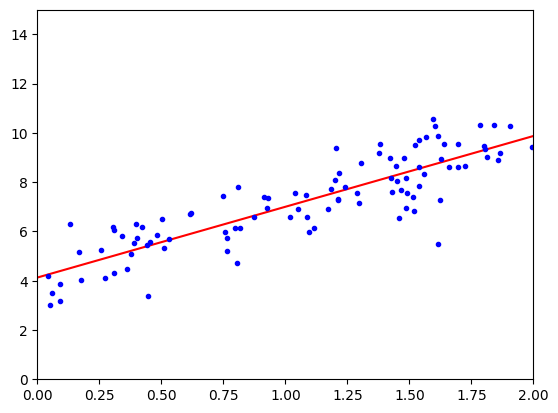

In [26]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

# Linear Regression hesablama

In [27]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.predict(X_new)

array([[4.12881986],
       [9.87261941]])

In [28]:
lin_reg.coef_ , lin_reg.intercept_


(array([[2.87189978]]), array([4.12881986]))

Esas xerc (X^T * X)^−1   hesablanmasidir

Az feature → Normal Equation

Çox feature və ya RAM-a sığmayan data → Gradient Descent əsaslı metodlar

# Gradient Descent


Linear Regression modeli üçün MSE cost function-u konveks funksiyadır. Bu o deməkdir ki, əyri üzərində istənilən iki nöqtəni götürsəniz, onları birləşdirən xətt parçası heç vaxt əyrini kəsməz. Bunun nəticəsi olaraq lokal minimumlar yoxdur, yalnız bir qlobal minimum mövcuddur. Bundan əlavə, bu funksiya kəsilməzdir və onun meyli (slope) qəfil dəyişmir. Bu iki faktın mühüm nəticəsi var: Gradient Descent, kifayət qədər uzun müddət işlədikdə və learning rate çox böyük olmadıqda, qlobal minimuma mütləq yaxınlaşır.

Gradient Descent-dən istifadə edərkən bütün xüsusiyyətlərin eyni miqyasda olmasına diqqət etmək lazımdır. əks halda alqoritmin konvergensiyası çox ləngiyəcək.

Bu diaqram həm də onu göstərir ki, modeli öyrətmək — training set üzərində cost function-u minimum edən parametrlər kombinasiyasını axtarmaqdır. Bu axtarış modelin parametr məkanında aparılır: modeldə nə qədər çox parametr varsa, bu məkan bir o qədər yüksək ölçülü olur və axtarış bir o qədər çətinləşir.

#### Xoşbəxtlikdən, Linear Regression üçün cost function konveks olduğuna görə, bu “iynə” sadəcə kasanın dibində yerləşir.

# Batch Gradient Descent


Gradient Descent-i tətbiq etmək üçün cost function-un hər bir model parametri θⱼ üzrə qradientini hesablamaq lazımdır. Yəni, θⱼ-də çox kiçik dəyişiklik etdikdə, xərc funksiyasının nə qədər dəyişdiyini tapırıq. Buna qismən törəmə (partial derivative) deyilir.

Gradient vektoru – ∇θ MSE(θ) – cost function-un bütün qismən törəmələrini özündə saxlayır (hər parametr üçün biri).

bu formul Gradient Descent-in hər addımında bütün training set X üzərində hesablamalar aparır. Məhz buna görə alqoritm Batch Gradient Descent adlanır: hər addımda bütün dataset istifadə olunur. 
* Nəticədə çox böyük training set-lərdə bu metod xeyli ləng işləyir
* Gradient Descent feature sayına görə yaxşı miqyaslanır: yüz minlərlə xüsusiyyət olduqda, Linear Regression-i Gradient Descent ilə öyrətmək Normal Equation-dan daha sürətlidir.

In [29]:
etas = [0.02 , 0.1 , 0.5]  # learning rate
for eta in  etas:
    n_iterations = 1000
    m = 100
    theta = np.random.randn(2,1)  # random initialization
    for iteration in range(n_iterations):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
    print(theta)


# Bu  normal  equation  ile tapilmis netice ile eynidir.

[[4.12151047]
 [2.87786028]]
[[4.12881986]
 [2.87189978]]
[[-6.89554304e+115]
 [-8.45603912e+115]]


* kicik (0.02) -  ile  alqoritm sonda həllə çatacaq, amma bu çox vaxt aparacaq.
* orta  (0.1)  -  cəmi bir neçə iterasiyada konvergensiya baş verir.
* boyuk (0.5)  - alqoritm diverge edir, hər addımda həllə yaxınlaşmaq əvəzinə ondan uzaqlaşır.

Yaxşı learning rate tapmaq üçün **grid search** istifadə oluna bilər, lakin bu zaman **iterasiya sayını məhdudlaşdırmaq** məsləhətdir ki, çox gec konvergensiya edən modellər avtomatik kənarlaşdırılsın.

O(1 / e) -iterasiya teleb olunur ,yeni  e (toleransi) azaaltsan  alqoritm cox isleyecek.

***Scikit-learn: Birbaşa ekvivalenti yoxdur (ancaq özünüz yaza bilərsiniz)**

# Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent hər addımda təsadüfi bir nümunə götürür və qradienti yalnız onun üzərində hesablayır.

Menfi terefi  ondadirki   teadufilik  tebiyetine malikdir , qradientler dalgalanirlar. Yungul  sicrayislarla azalir , yalniz ortalama olaraq minimuma yaxinlasirlar, egtdikce cox yaxin olurlar amma sabitlesmirler ,yeni  prametrler optimal olmur amma yaxin olur.

**SGD üçün miqyaslandırma (scaling) ÇOX VACİBdir, yoxsa alqoritm işləməz**

In [30]:
theta = np.random.randn(2,1)
theta


array([[-1.33764397],
       [ 0.6592734 ]])

In [31]:
n_epochs = 50 
t0 , t1 = 5 , 50
m = 100 
theta = np.random.randn(2,1)


X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
X_b = np.c_[np.ones((100, 1)), X]  

def learning_schedule(t):
    return  t0 / (t + t1)

for epoch in  range(n_epochs):
    for i  in range(m):
        random_index = np.random.randint(m) #  tesadufi  indeks secilir

        xi = X_b[random_index:random_index+1]  # x secilir tesadufi
        yi = y[random_index:random_index+1]     # y  secilir tesadufi
        
        eta       =  learning_schedule( epoch * m + i )
        gradients =  2 * xi.T.dot(xi.dot(theta) - yi) 
        theta     = theta -  eta * gradients

theta

array([[4.60426395],
       [2.61582084]])

### Linear Regression-i SGD

Məsələn, aşağıdakı kod 50 epoch, learning rate 0.1 (eta0=0.1) və default learning schedule ilə modeli öyrədir, regularization istifadə etmir (penalty=None):

In [32]:
from  sklearn.linear_model import  SGDRegressor
sgd_reg = SGDRegressor( max_iter = 50 ,
                        penalty=None ,
                        eta0 = 0.1)
sgd_reg.fit(X,y.ravel())            #  ravel  -  1D ye ceviri

sgd_reg.intercept_ ,sgd_reg.coef_ ,

(array([4.53681064]), array([2.63412048]))

***Scikit-learn: SGDRegressor və ya SGDClassifier**

## Mini-batch Gradient Descent

Hər addımda bütün dataset (Batch GD) və ya tək nümunə (SGD) əvəzinə, kiçik təsadüfi nümunə qrupları (mini-batches) üzərində qradientləri hesablayır.

Ustunluk:

Mini-batch GD, matrix əməliyyatlarının hardware optimizasiyasından, xüsusilə GPU-lardan, fayda götürə bilir.

Parametr məkanında hərəkət SGD-dən daha az dalğalanır, minimuma daha yaxın dayanır.

Məhdudiyyətlər:

Lokal minimumlardan çıxmaq çətin ola bilər (Linear Regression üçün problem deyil, lakin bəzi digər modellərdə ola bilər).

**Scikit-learn: SGDRegressor (batch_size parametri ilə)**



**Scikit-learn-də həm SGD, həm də Mini-batch GD SGDRegressor ilə edilir, sadəcə batch_size parametri ilə fərqlənir**

## UMUMI Netice 


| Algorithm       | Large m | Out-of-core | Large n | Hyperparams | Scaling required | Scikit-Learn     |
| --------------- | ------- | ----------- | ------- | ----------- | ---------------- | ---------------- |
| Normal Equation | Fast    | No          | Slow    | 0           | No               | LinearRegression |
| Batch GD        | Slow    | No          | Fast    | 2           | Yes              | ozumuz elle             |
| Stochastic GD   | Fast    | Yes         | Fast    | ≥2          | Yes              | SGDRegressor     |
| Mini-batch GD   | Fast    | Yes         | Fast    | ≥2          | Yes              | SGDRegressor     |


---------------------------------------------------------------------------

--------------------------------------------------------------------------------

## Polynomial Regression

Əgər data sadə düz xəttdən daha mürəkkəbdirsə, təəccüblü olsa da, linear model ilə belə nonlinear datanı uyğunlaşdırmaq olar. Sadə üsul: hər bir xüsusiyyətin qüvvələrini yeni xüsusiyyət kimi əlavə etmək və sonra linear model-i bu genişləndirilmiş feature set üzərində öyrətməkdir. Bu texnika Polynomial Regression adlanır.

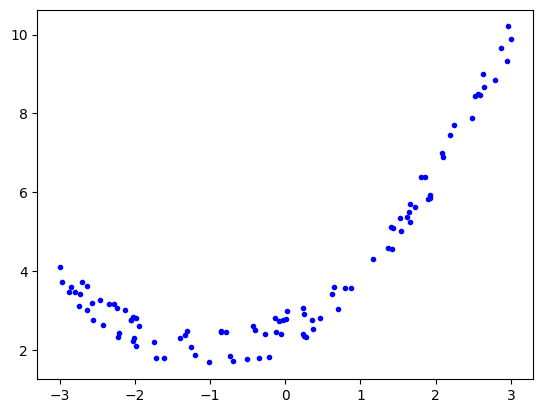

In [33]:
m =100 

X = 6 * np.random.rand(m,1) - 3
y = 0.5 * (X**2) + X + 2 + np.random.rand(m,1)

plt.plot(X,y,'b.')
plt.show()

Scikit-Learn-in PolynomialFeatures sinfi ilə training data-nı transformasiya edək və hər bir xüsusiyyətin kvadratı (2-ci dərəcəli polinom) yeni xüsusiyyət kimi əlavə olunsun (bu nümunədə yalnız bir xüsusiyyət var):

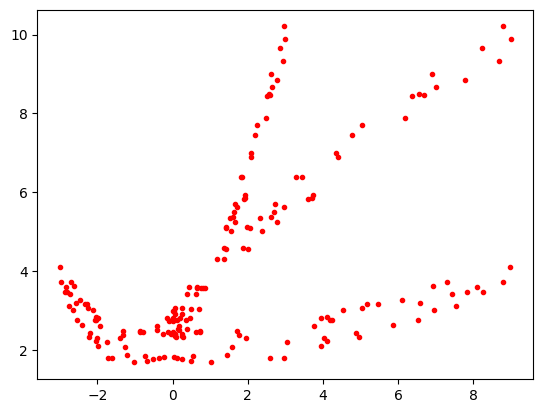

In [34]:
from  sklearn.preprocessing  import  PolynomialFeatures

poly_features = PolynomialFeatures( degree=2,include_bias=False)
X_poly        = poly_features.fit_transform(X)

plt.plot(X_poly[0:100],y,'r.')


İndi X_poly orijinal xüsusiyyət ilə birlikdə onun kvadratını da ehtiva edir. Bu genişləndirilmiş dataset üzərində LinearRegression modelini öyrətmək olar:

yuxaridaki  orginal funksiya ile oxsar neticeleri texmin edir.


In [35]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly , y)
lin_reg.intercept_ , lin_reg.coef_

(array([2.50585079]), array([[1.00855215, 0.49675095]]))

#  Learning Curves

Təbii ki, bu yüksək dərəcəli polinom modeli ağır overfitting edir, xətti model isə underfitting göstərir. Bu halda ən yaxşı generalizasiya edən model kvadratik modeldir. Burada bu məntiqlidir, çünki data kvadratik funksiya ilə yaradılıb. Amma real həyatda adətən datanı yaradan funksiyanı bilmirsiniz.

Learning curves — training set ölçüsündən (və ya iterasiyadan) asılı olaraq:

+ training performansı

+ validation performansı qrafikləridir.

Bu qrafikləri almaq üçün model müxtəlif ölçülü training subset-lər üzərində bir neçə dəfə öyrədilir.

In [36]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []

    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m]) # Train  set her defe artir
        y_val_predict = model.predict(X_val)    #  validation set sabit qalir

        train_errors.append(mean_squared_error(y_train_predict, y_train[:m]))
        val_errors.append(mean_squared_error(y_val_predict, y_val))
    print(train_errors," train  error")
    print(val_errors,"val_error")
    
    plt.xlabel(xlabel='Training set size')
    plt.ylabel(ylabel='RMSE')
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors)  , "b-" , linewidth=3, label="val")

[0.0, 0.0, 0.0018109740837862487, 0.024195710003935222, 0.14932155616737472, 1.9951773785097273, 1.7102325173560857, 1.6033947183288326, 1.4450680490977108, 1.324364570888076, 1.2040023602198344, 1.312012020362307, 1.3894149345967222, 1.6933004457045004, 1.6187070120865377, 1.6699337468446833, 1.5840442698702784, 1.532352431080907, 1.4549389548308813, 1.421372577194782, 1.6250107701471368, 1.5533444196587747, 1.6390876832208354, 1.6312184393143598, 1.60679947980271, 1.5450313978828087, 1.4882686607089313, 1.5121256018443423, 1.6672900624381173, 1.615844814420273, 1.6302291037571046, 1.6265502821382891, 1.5904494712831203, 1.5582783347184181, 1.6188718002572988, 1.6881824743204894, 1.8429607310827258, 1.8581960027934676, 1.8321057920360715, 1.8003869573622602, 1.7567576504825224, 1.7526503041265709, 1.716757403702313, 1.7674295313713393, 1.7298856474924664, 1.7644450155253892, 1.727212564892776, 1.9500137683405743, 1.9246193263552747, 1.9302349632907159, 2.01221319970122, 1.986232679810

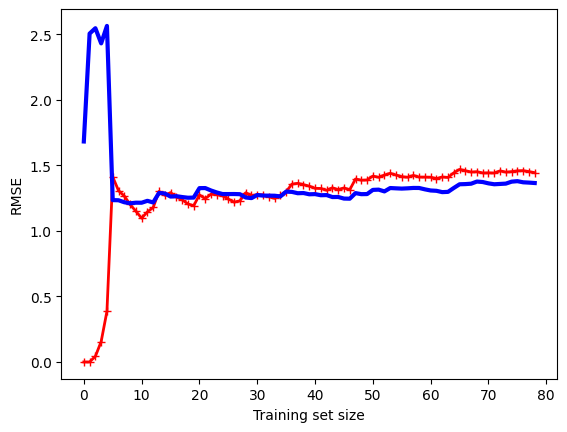

In [37]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

[0.0, 9.860761315262648e-32, 3.497283346479819e-29, 3.1377435543231508e-27, 2.501197884834475e-26, 1.1404989406437162e-26, 7.549809352371835e-25, 8.48346662760529e-25, 8.743412210048738e-24, 3.0190951886197615e-22, 3.413873959464095e-21, 0.001031815871591672, 0.0012301193684217241, 0.01600437169622276, 0.022155791415708597, 0.021462579929055838, 0.02024821129025994, 0.023307304360282517, 0.026183638995088843, 0.028013243252181862, 0.030374056304121346, 0.02936808563435919, 0.04154691242295746, 0.04096583425352341, 0.03955302119015718, 0.03913093296703891, 0.046957938741194735, 0.04649465493695546, 0.04607108152508729, 0.04903007412655238, 0.04881560804574052, 0.04870090874554984, 0.05108382901722977, 0.04971977609962343, 0.05002750640264203, 0.05079598170324176, 0.050153857912225944, 0.050404022804899626, 0.053742195997370686, 0.05995253697263385, 0.06204578464183503, 0.06570166161989473, 0.06645358050956375, 0.06499628828946923, 0.06451891989715519, 0.06728822005841834, 0.076237097450

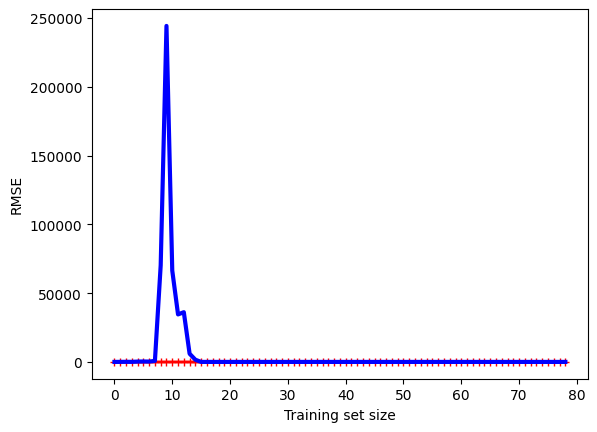

In [38]:

from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
        ("lin_reg",       LinearRegression()),
    ])
plot_learning_curves(polynomial_regression, X, y)

Təlim datası üzərində xəta Linear Regression modeli ilə müqayisədə xeyli aşağıdır.

Əyrilər arasında boşluq var. Bu o deməkdir ki, model təlim datasında validation datasına nisbətən xeyli daha yaxşı performans göstərir ki, bu da overfitting edən modelin əsas əlamətidir. Lakin daha böyük bir təlim dəsti istifadə etsəydiniz, bu iki əyri tədricən bir-birinə yaxınlaşardı.

### Bias / Variance Tradeoff

Modelin mürəkkəbliyini artırmaq adətən variance-ı artırır və bias-ı azaldır. Əksinə, modelin mürəkkəbliyini azaltmaq bias-ı artırır və variance-ı azaldır. Buna görə də bu münasibət tradeoff adlanır.

# Regularized Linear Models

Overfitting-i azaltmağın effektiv yolu modeli regularizasiya etməkdir (yəni onu məhdudlaşdırmaq). Modelin sərbəstlik dərəcələri nə qədər az olarsa, datanı overfit etməsi bir o qədər çətin olar. 

Məsələn, polinomial model üçün sadə regularizasiya üsulu polinomun dərəcəsini azaltmaqdır.

Xətti modellərdə isə regularizasiya adətən modelin çəkilərini (weights) məhdudlaşdırmaqla həyata keçirilir. Bu məqsədlə üç əsas yanaşmaya baxacağıq: Ridge Regression, Lasso Regression və Elastic Net

Regularizasiya yalnız təlim zamanı tətbiq edilir; qiymətləndirmə isə regularizasiyasız metriklə aparılır.

Vacib: Ridge Regression xüsusiyyətlərin miqyasına həssasdır; buna görə feature scaling (məs., StandardScaler) mütləqdir.

In [39]:
from  sklearn.linear_model import  Ridge

ridge_reg = Ridge(alpha=0.1 , solver='cholesky')
ridge_reg.fit(X,y)
ridge_reg.predict([[1.5]])



array([5.57100233])

In [40]:
sgd_reg = SGDRegressor(penalty='l2') # l2 - ridge regression demekdir SGD ucun
sgd_reg.fit(X,y.ravel())
sgd_reg.predict([[1.5]])

array([5.55575877])

# Lasso Regression


Lasso-nun əsas xüsusiyyəti ondan ibarətdir ki, əhəmiyyətsiz xüsusiyyətlərin çəkilərini tam sıfıra endirməyə meyllidir. Bu səbəbdən Lasso:

+ avtomatik feature selection edir,

+ sparse model (az sayda sıfırdan fərqli çəki) yaradır.

**L1 xərc funksiyası** (Lasso) `θᵢ = 0`-da diferensiallanmır. Gradient Descent bunu **subgradient** ilə həll edir:

**Gradiyent düsturu:**  
`g = ∇θ MSE(θ) + α ⋅ sign(θ)`

**sign(θ) funksiyası:**
- `-1` əgər θᵢ < 0
- `0` əgər θᵢ = 0  
- `+1` əgər θᵢ > 0

**Vacib qeyd:** L1-nin kəskin maililiyi səbəbindən, **learning rate tədricən azaldılmalıdır**, yoxsa optimallaşdırıcı minimum ətrafında sıçrayar.

In [41]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])


array([5.52249592])

# Elastic Net

Elastic Net Ridge Regression ilə Lasso Regression arasında bir kompromisdir. Regularizasiya termini bu iki üsulun qarışığından ibarətdir və qarışıq nisbəti r ilə idarə olunur:

+ r = 0 → Ridge Regression

+ r = 1 → Lasso Regression

* Ridge: yaxşı default seçimdir.

* Lasso: yalnız az sayda feature-in vacib olduğunu düşünürsənsə.

* Elastic Net: praktikada çox vaxt Lasso-dan üstündür, çünki:

       + feature sayı nümunə sayından çox olduqda,

      + və ya feature-lər güclü korrelyasiyalı olduqda,
       Lasso qeyri-sabit davrana bilər.

In [42]:
from  sklearn.linear_model import  ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio = 0.5) # l1_ratio parametri r qarışıq nisbətinə uyğundur
elastic_net.fit(X,y)
elastic_net.predict([[1.5]])

array([5.52482206])

# Early Stopping

ERken dayanma iterativ oyrenme alq ucub  requlyarizasiya etmeyin  sade ve effektiv yoludur .Validation xetasi  minimuma catdiginda telim dayanir. 
+ Telim davam edende training xetasi azalri
+ Validation azalir daha sonra artirsa bu  overfittingdir. 
+ Early stoppping hemin  minimum noqtede dayanir

Stoxastik  ve mini-de eyri ses kuylu olduguna gore minimumu gormek cetindir 

Validation xətası bir müddət minimumdan yuxarı qaldıqdan sonra dayandırmaq və ən yaxşı epoch-dakı parametrlərə geri qayıtmaqdır.

In [43]:
from sklearn.base import  clone   # sklearn modelinin dəqiq surətini yaratmaq üçün
from  sklearn.preprocessing import  StandardScaler

# np.random.seed(42)

# m = 100
# X = 6 * np.random.rand(m, 1) - 3
# y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )


poly_scaler= Pipeline([
    ('poly_features', PolynomialFeatures(degree=90,include_bias=False)),
    ('std_scaler' , StandardScaler())
])

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled   = poly_scaler.transform(X_val)

sgd_reg = SGDRegressor( max_iter = 1,         # Hər fit() çağırışında YALNIZ 1 epoch/iteration icra edir
                         warm_start = True,   # hər çağırışda təlimi sıfırdan başlamır, qaldığı yerdən davam edir.
                          penalty = None,      # Regularizasiya YOXDUR
                          learning_rate = "constant", # Sabit öyrənmə sürəti
                            eta0 = 0.0005  )   # Öyrənmə sürətinin dəyəri (çox kiçik)

minimum_val_error = float("inf") # ən kiçik validasiya xətası (başlanğıcda sonsuz)
best_epoch = None
best_model = None

for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train)  # 1000 defe her defe  1 iterasiya ve qaldigi veziyyetden

    y_val_predict = sgd_reg.predict(X_val_poly_scaled)  # prediction 
    val_error = mean_squared_error(y_val_predict, y_val) #  mse hesablanir

    if val_error < minimum_val_error:
        minimum_val_error = val_error     # Minimum xətanı yenilə
        best_epoch = epoch               #Ən yaxşı epochu qeyd et
        best_model = clone(sgd_reg)     # Modelin DƏQİQ surətini saxla (clone istifadəsi vacibdir!)

NameError: name 'X_train' is not defined

# Logistic Regression

Logistic Regression (və ya Logit Regression) adətən bir obyektin müəyyən bir sinfə aid olma ehtimalını qiymətləndirmək üçün istifadə olunur (məsələn, bu e-poçtun spam olma ehtimalı nə qədərdir?).

Əgər hesablanan ehtimal 50%-dən böyükdürsə, model həmin obyektin bu sinfə aid olduğunu proqnozlaşdırır (müsbət sinif, etiket “1”). Əks halda, onun bu sinfə aid olmadığını qəbul edir (mənfi sinif, etiket “0”).

Bu səbəbdən Logistic Regression ikili klassifikatordur.

Xətti təxmini, çıxışı 0 ilə 1 arasında olan bir ehtimala çevirmək üçün sigmoid/logistik funksiyadan keçiririk. 

Əldə edilən 
p
p dəyəri müsbət sinifə (y=1) aid olma ehtimalını ifadə edir:  |p=P(y=1∣x;θ).

Ehtimal əsasında son proqnoz, adətən 0.5 kəsişmə nöqtəsi ilə verilir (tərcümənizdə olduğu kimi):
__y ={0,p<0.5   -  1,p≥0.5}__
​

Vacib qeyd: 0.5 həmişə default kəsişmə nöqtəsidir, lakin bu, əyri tarazlıq (class imbalance) və ya səhv qiymətlərin fərqli dəyərləri olduğu hallarda dəyişdirilə bilər.

### Training and Cost Function

+ müsbət nümunələr (y = 1) üçün ehtimal yüksək,

+ mənfi nümunələr (y = 0) üçün ehtimal aşağı olsun.

+ y=1 -de  - log(p)
+ y=0 -da  - log(1-p)

J = - 1/m  * (y * log(p)  + (1-y)*log(1-p))

dJ / dO = 1/m * ( sigmoid(O^T * x)- y) * x

# Decision Boundaries

Decision boundary — modelin iki sinif arasında “qərar verdiyi” sərhəddir.
Logistic Regression üçün bu sərhəd p = 0.5 şərti ilə müəyyən olunur.

Çünki:

𝑝≥0.5 ⇒ p≥0.5⇒ sinif 1

𝑝<0.5 ⇒ p<0.5⇒ sinif 0

In [45]:
from  sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [46]:
X= iris['data'][: , 3:]    #  petal witdh
y =(iris['target']==2).astype(np.int64) # 2-leri 1 edir, qalan hamsin 0 edir

In [47]:
from  sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

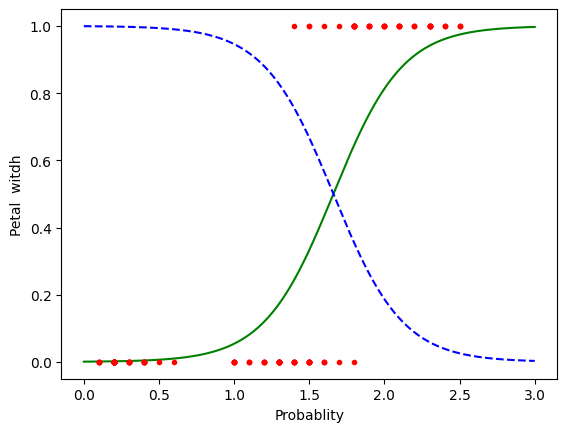

In [ ]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.xlabel('Probablity')
plt.ylabel('Petal  witdh')
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris-Virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris-Virginica")
plt.plot(X,y,'r.')

Sekildende gorunduyu kimi  decison  boundry  - __1.6__ dir .  Bu halda ondan boyuk  reqemler avtomatik  1 kimi  ,  asagi  reemler ise 0  kimi  predict  edilecek . 1.6 ise 0  kimi  olacaq

In [49]:
log_reg.predict([[1.7], [1.5]])
# [1, 0]
# yeni  1.7 iris-dir amma 1.5 deyil

array([1, 0])

+ model θᵀx = 0 tipli şərt istifadə edir

+ feature-lar xəttidirsə → sərhəd də xəttidir

Polynomial features əlavə etsən:

__Logistic Regression qalır  , amma decision boundary qeyri-xətti olur__

### Requlyarizasiya - istifade edilir ,  default olaraq L2 ist edir , c = 1 /a 

C böyükdür → az regularization → daha sərt boundary

C kiçikdir → çox regularization → daha hamar boundary

# Softmax (Multinomial Logistic) Regression

Binary Logistic Regression -   yalniz {0,1} hal  ucun dogrudur . 
amma real hallarda {0,1,2,...., k-1} 

Softmax - bu  coxsinifli  problemi    1 optimizasiya ,  1 model ,  birlesdirilmis ehtimal  mekaninda hell  edir .

### SCore -nedir ? 

Her sinif ucun  ayrica xetti model  var :
s(x) = O^T * x
+ O^T -  k-ci sinif ucun  ceki  vektoru
+ S(x) - score (legit)
Bu merhelede hec bir ehtmial deyil  ,  nisbi  ustunluk  olculur

#### softmax  funksiyasi 
P = exp(S(x)) / cem (exp(S(X))



## Proqnoz

y = arg max sigmoid(S(x)) =  arg max sigmoid ( O^T * x)

Softmax Regression eyni anda yalnız bir sinfi proqnozlaşdırır. Yəni bu model:

+ multiclass-dır (çox siniflidir),

+ amma multioutput deyil (bir nümunə üçün birdən çox etiket qaytara bilməz).

In [ ]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

softmax_reg = LogisticRegression(solver="lbfgs", C=10)
softmax_reg.fit(X, y)
softmax_reg.predict([[5, 2]])
softmax_reg.predict_proba([[5, 2]])


# Çoxsinifli məsələlərdə (n_classes >= 3) model avtomatik olaraq 
# "lbfgs" kimi uyğun solver-lar ilə multinomial loss (yəni Softmax) istifadə edir

array([[6.21626370e-07, 5.73689802e-02, 9.42630398e-01]])